# 🌿 KISAAN AI — Plant Disease CNN
### MobileNetV2 Transfer Learning on PlantVillage
**Run on Colab with GPU (Runtime → Change runtime type → T4 GPU)**

## Step 1 — Mount Drive + Install Kaggle

In [ ]:
# Install kaggle API
!pip install kaggle -q

## Step 2 — Upload kaggle.json
Go to kaggle.com → Account → Create New Token → download kaggle.json → upload below

In [ ]:
from google.colab import files
files.upload()  # upload your kaggle.json here

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('✅ Kaggle configured')

Saving kaggle (1).json to kaggle (1) (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle configured


## Step 3 — Download PlantVillage Dataset

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/plantvillage --unzip -q
print('✅ Dataset downloaded')

# Find the actual image folder
import os
for root, dirs, files in os.walk('/content/plantvillage'):
    if dirs:
        print(f'Found folder: {root}')
        print(f'  Subfolders: {len(dirs)}')
        break

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
✅ Dataset downloaded
Found folder: /content/plantvillage
  Subfolders: 1


## Step 4 — Setup & Explore

In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

# ── Find dataset path ────────────────────────────────────────────────────────
# PlantVillage has 3 variants: color, grayscale, segmented — use color
DATA_DIR = None
for root, dirs, files in os.walk('/content/plantvillage'):
    if 'color' in root.lower() and len(dirs) > 10:
        DATA_DIR = root
        break

if DATA_DIR is None:
    # fallback — find folder with most subfolders
    best, best_count = None, 0
    for root, dirs, files in os.walk('/content/plantvillage'):
        if len(dirs) > best_count:
            best, best_count = root, len(dirs)
    DATA_DIR = best

print(f'\n✅ Using dataset at: {DATA_DIR}')
classes = sorted(os.listdir(DATA_DIR))
print(f'Classes found: {len(classes)}')
total_images = sum(len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes)
print(f'Total images: {total_images:,}')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ Using dataset at: /content/plantvillage/plantvillage dataset/color
Classes found: 38
Total images: 54,305


In [ ]:
# Show class distribution
counts = [(c, len(os.listdir(os.path.join(DATA_DIR, c)))) for c in classes]
counts.sort(key=lambda x: -x[1])

print('Class distribution (top 10):')
for name, count in counts[:10]:
    bar = '█' * (count // 100)
    print(f'  {name[:45]:<45} {count:5d} {bar}')

healthy = [c for c in classes if 'healthy' in c.lower()]
diseased = [c for c in classes if 'healthy' not in c.lower()]
print(f'\nHealthy classes : {len(healthy)}')
print(f'Diseased classes: {len(diseased)}')

Class distribution (top 10):
  Orange___Haunglongbing_(Citrus_greening)       5507 ███████████████████████████████████████████████████████
  Tomato___Tomato_Yellow_Leaf_Curl_Virus         5357 █████████████████████████████████████████████████████
  Soybean___healthy                              5090 ██████████████████████████████████████████████████
  Peach___Bacterial_spot                         2297 ██████████████████████
  Tomato___Bacterial_spot                        2127 █████████████████████
  Tomato___Late_blight                           1909 ███████████████████
  Squash___Powdery_mildew                        1835 ██████████████████
  Tomato___Septoria_leaf_spot                    1771 █████████████████
  Tomato___Spider_mites Two-spotted_spider_mite  1676 ████████████████
  Apple___healthy                                1645 ████████████████

Healthy classes : 12
Diseased classes: 26


## Step 5 — Build Data Pipelines

In [ ]:
IMG_SIZE   = 224   # MobileNetV2 native size
BATCH_SIZE = 32
EPOCHS_1   = 5    # Phase 1: train head only (frozen base)
EPOCHS_2   = 10   # Phase 2: fine-tune top layers

# ── Augmentation for training ────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

NUM_CLASSES = len(train_gen.class_indices)
print(f'\n✅ Train batches : {len(train_gen)}')
print(f'   Val batches   : {len(val_gen)}')
print(f'   Num classes   : {NUM_CLASSES}')

# Save class labels mapping — Flask needs this
class_indices = train_gen.class_indices   # {class_name: int_index}
idx_to_class  = {v: k for k, v in class_indices.items()}
print('\nSample classes:', list(idx_to_class.values())[:5])

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.

✅ Train batches : 1358
   Val batches   : 340
   Num classes   : 38

Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## Step 6 — Build MobileNetV2 Model

In [ ]:
def build_model(num_classes, trainable_base=False):
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model(NUM_CLASSES, trainable_base=False)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print(f'Total params    : {model.count_params():,}')
print(f'Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')
print('\nModel ready ✅')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params    : 2,628,838
Trainable params: 368,294

Model ready ✅


## Step 7 — Phase 1 Training (Frozen Base)

In [ ]:
callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint('/content/best_phase1.keras', save_best_only=True, monitor='val_accuracy', verbose=1)
]

print('Phase 1: Training classification head (base frozen)...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_1,
    callbacks=callbacks_p1,
    verbose=1
)

p1_acc = max(history1.history['val_accuracy'])
print(f'\n✅ Phase 1 complete — best val accuracy: {p1_acc:.4f} ({p1_acc*100:.1f}%)')

Phase 1: Training classification head (base frozen)...
Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.6395 - loss: 1.3226 - top3_acc: 0.8019
Epoch 1: val_accuracy improved from None to 0.89243, saving model to /content/best_phase1.keras

Epoch 1: finished saving model to /content/best_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 685s 488ms/step - accuracy: 0.7491 - loss: 0.8618 - top3_acc: 0.8971 - val_accuracy: 0.8924 - val_loss: 0.3256 - val_top3_acc: 0.9821 - learning_rate: 0.0010
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8377 - loss: 0.5290 - top3_acc: 0.9569
Epoch 2: val_accuracy improved from 0.89243 to 0.92101, saving model to /content/best_phase1.keras

Epoch 2: finished saving model to /content/best_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 641s 472ms/step - accuracy: 0.8470 - loss: 0.4988 - top3_acc: 0.9597 - val_accuracy: 0.9210 - val_loss: 0.2410 - val_top3_acc: 0.9882 - learning_rate: 0.0010
Epoch 3/5
1358/1358 ━━━━━━━━━━━━

## Step 8 — Phase 2 Fine-tuning (Unfreeze Top Layers)

In [ ]:
# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen layers: {trainable_count} / {len(base_model.layers)}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('/content/best_phase2.keras', save_best_only=True, monitor='val_accuracy', verbose=1)
]

print('\nPhase 2: Fine-tuning top layers...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_2,
    callbacks=callbacks_p2,
    verbose=1
)

p2_acc = max(history2.history['val_accuracy'])
print(f'\n✅ Phase 2 complete — best val accuracy: {p2_acc:.4f} ({p2_acc*100:.1f}%)')

Unfrozen layers: 30 / 154

Phase 2: Fine-tuning top layers...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8643 - loss: 0.4529 - top3_acc: 0.9636
Epoch 1: val_accuracy improved from None to 0.92147, saving model to /content/best_phase2.keras

Epoch 1: finished saving model to /content/best_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 663s 475ms/step - accuracy: 0.8916 - loss: 0.3670 - top3_acc: 0.9742 - val_accuracy: 0.9215 - val_loss: 0.2696 - val_top3_acc: 0.9844 - learning_rate: 1.0000e-04
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9228 - loss: 0.2521 - top3_acc: 0.9865
Epoch 2: val_accuracy improved from 0.92147 to 0.95142, saving model to /content/best_phase2.keras

Epoch 2: finished saving model to /content/best_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 647s 477ms/step - accuracy: 0.9280 - loss: 0.2362 - top3_acc: 0.9872 - val_accuracy: 0.9514 - val_loss: 0.1603 - val_top3_acc: 0.9946 - learning_rate: 1.0000e-04
Epoch 3/10
1358

## Step 9 — Evaluate

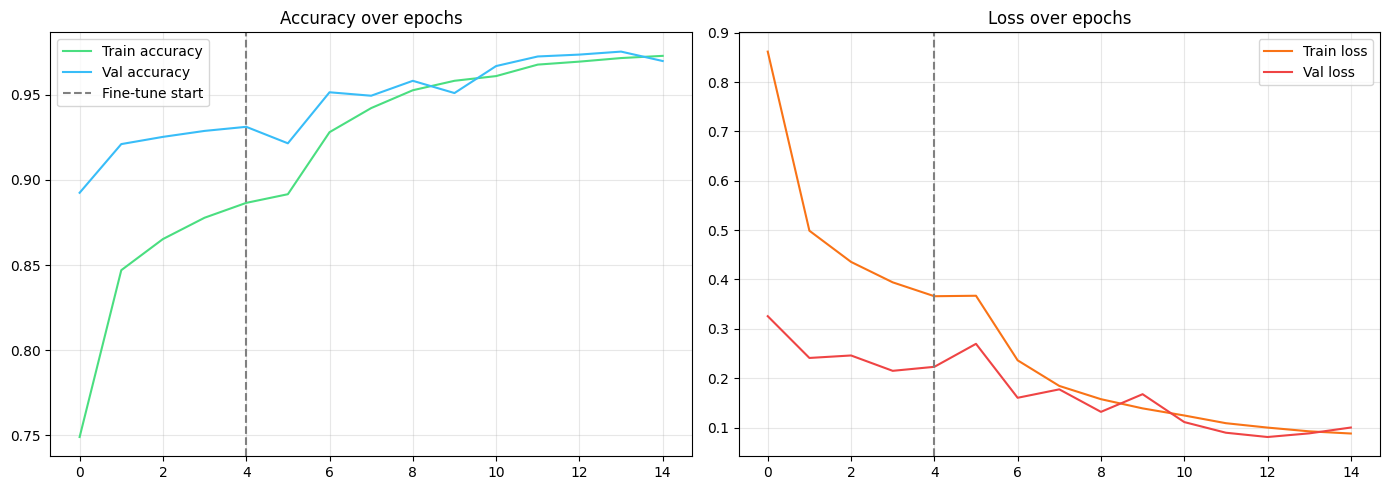

Saved: training_curves.png


In [ ]:
# Plot training curves
all_acc = history1.history['accuracy'] + history2.history['accuracy']
all_val = history1.history['val_accuracy'] + history2.history['val_accuracy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_acc, label='Train accuracy', color='#4ade80')
ax1.plot(all_val, label='Val accuracy', color='#38bdf8')
ax1.axvline(x=len(history1.history['accuracy'])-1, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy over epochs')
ax1.legend(); ax1.grid(alpha=0.3)

all_loss = history1.history['loss'] + history2.history['loss']
all_vloss = history1.history['val_loss'] + history2.history['val_loss']
ax2.plot(all_loss, label='Train loss', color='#f97316')
ax2.plot(all_vloss, label='Val loss', color='#ef4444')
ax2.axvline(x=len(history1.history['loss'])-1, color='gray', linestyle='--')
ax2.set_title('Loss over epochs')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [ ]:
# Full evaluation on validation set
print('Evaluating on validation set...')
val_gen.reset()
loss, acc, top3 = model.evaluate(val_gen, verbose=1)
print(f'\n=== FINAL RESULTS ===')
print(f'Val Accuracy  : {acc:.4f} ({acc*100:.1f}%)')
print(f'Top-3 Accuracy: {top3:.4f} ({top3*100:.1f}%)')
print(f'Val Loss      : {loss:.4f}')
print(f'Num classes   : {NUM_CLASSES}')

Evaluating on validation set...
340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.9753 - loss: 0.0882 - top3_acc: 0.9975

=== FINAL RESULTS ===
Val Accuracy  : 0.9753 (97.5%)
Top-3 Accuracy: 0.9975 (99.8%)
Val Loss      : 0.0882
Num classes   : 38


## Step 10 — Save Model + Labels for Flask

In [ ]:
import json, re

# ── Save Keras model ─────────────────────────────────────────────────────────
MODEL_PATH  = '/content/plant_disease_cnn.h5'
LABELS_PATH = '/content/cnn_class_labels.json'

model.save(MODEL_PATH)
print(f'✅ Model saved: {MODEL_PATH}')

# ── Build clean labels dict ──────────────────────────────────────────────────
# PlantVillage format: 'Tomato___Early_blight' or 'Apple___healthy'
# We want: { 0: {'crop': 'Tomato', 'disease': 'Early blight', 'is_healthy': False} }

def parse_class(class_name):
    """Parse PlantVillage class name into structured dict."""
    # Handle both ___ and __ separators
    if '___' in class_name:
        parts = class_name.split('___', 1)
    elif '__' in class_name:
        parts = class_name.split('__', 1)
    else:
        parts = [class_name, 'unknown']

    crop    = parts[0].replace('_', ' ').strip()
    disease = parts[1].replace('_', ' ').strip()
    is_healthy = 'healthy' in disease.lower()

    # Treatment suggestions per disease keyword
    treatment = get_treatment(disease, crop)

    return {
        'crop'      : crop,
        'disease'   : disease,
        'is_healthy': is_healthy,
        'treatment' : treatment
    }

def get_treatment(disease, crop):
    disease_l = disease.lower()
    if 'healthy' in disease_l:
        return 'No treatment needed. Crop looks healthy.'
    elif any(x in disease_l for x in ['blight', 'phytophthora']):
        return 'Apply copper-based fungicide. Improve drainage. Remove infected leaves.'
    elif any(x in disease_l for x in ['rust', 'puccinia']):
        return 'Apply triazole fungicide. Avoid overhead irrigation. Use resistant varieties.'
    elif any(x in disease_l for x in ['spot', 'cercospora', 'alternaria']):
        return 'Apply mancozeb or chlorothalonil. Ensure proper plant spacing.'
    elif any(x in disease_l for x in ['mildew', 'powdery', 'blumeria']):
        return 'Apply sulfur or potassium bicarbonate spray. Improve air circulation.'
    elif any(x in disease_l for x in ['mosaic', 'virus', 'curl']):
        return 'No chemical cure. Remove infected plants. Control aphid vectors.'
    elif any(x in disease_l for x in ['scab', 'black rot']):
        return 'Apply captan or myclobutanil. Prune infected branches. Rake fallen leaves.'
    elif 'greening' in disease_l or 'huanglongbing' in disease_l:
        return 'No cure. Remove infected trees. Control psyllid insects.'
    else:
        return 'Consult local agronomist. Apply broad-spectrum fungicide as precaution.'

labels_dict = {str(idx): parse_class(class_name)
               for class_name, idx in class_indices.items()}

with open(LABELS_PATH, 'w') as f:
    json.dump(labels_dict, f, indent=2)

print(f'✅ Labels saved: {LABELS_PATH}')
print(f'   Total classes: {len(labels_dict)}')

# Preview a few
print('\nSample entries:')
for k in list(labels_dict.keys())[:5]:
    print(f'  [{k}] {labels_dict[k]}')

In [ ]:
# ── Quick inference test ─────────────────────────────────────────────────────
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image

def predict_disease(img_path, top_k=3):
    img = keras_image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]
    top_indices = np.argsort(preds)[::-1][:top_k]

    results = []
    for idx in top_indices:
        info = labels_dict[str(idx)]
        results.append({
            'rank'      : len(results) + 1,
            'crop'      : info['crop'],
            'disease'   : info['disease'],
            'is_healthy': info['is_healthy'],
            'confidence': round(float(preds[idx]) * 100, 2),
            'treatment' : info['treatment']
        })
    return results

# Test with a random val image
import random
random_class = random.choice(os.listdir(DATA_DIR))
random_img_dir = os.path.join(DATA_DIR, random_class)
random_img = os.path.join(random_img_dir, random.choice(os.listdir(random_img_dir)))

print(f'Testing with: {random_class}')
result = predict_disease(random_img)
for r in result:
    print(f"  Rank {r['rank']}: {r['crop']} — {r['disease']} ({r['confidence']}%)")

## Step 11 — Download Files to Your PC

In [ ]:
# Download both files — put them in backend/models/
from google.colab import files

print('Downloading plant_disease_cnn.h5 ...')
files.download(MODEL_PATH)

print('Downloading cnn_class_labels.json ...')
files.download(LABELS_PATH)

import os
size_mb = os.path.getsize(MODEL_PATH) / (1024*1024)
print(f'\nModel size: {size_mb:.1f} MB')
print('\n✅ Done! Place both files in: backend/models/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Model size: 24.9 MB

✅ Done! Place both files in: backend/models/


## Summary
After running all cells you will have:
- `plant_disease_cnn.h5` — trained MobileNetV2 model (~14MB)
- `cnn_class_labels.json` — maps index → {crop, disease, is_healthy, treatment}

Place both in `backend/models/` then proceed to update `app.py` and `dashboard.html`.